In [65]:
%pip install scikit-learn
%pip install pandas
%pip install seaborn




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [66]:
import sys
print(sys.version)

3.12.1 (main, Mar 11 2026, 12:17:56) [GCC 13.3.0]


In [67]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [68]:
con = sqlite3.connect('ProjectData/gas_monitoring.db')

cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        
        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]
query = "SELECT * FROM gas_monitoring"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)

CHECKING DATA

In [69]:
print(df.shape)
for cols in df:
    print(cols)

(10000, 14)
Time of Day
Temperature
Humidity
CO2_InfraredSensor
CO2_ElectroChemicalSensor
MetalOxideSensor_Unit1
MetalOxideSensor_Unit2
MetalOxideSensor_Unit3
MetalOxideSensor_Unit4
CO_GasSensor
Session ID
HVAC Operation Mode
Ambient Light Level
Activity Level


Table has 14 columns and 10000 rows

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  str    
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  str    
 12  Ambient Light Level        8946 non-null   str    
 13  Activity Level             10000 non-null  str    
dtypes:

0. might have to standardise time of day 

1-10. Check numerics for outliers, maybe check if some readings correspond to celcius/farenheit counterpart

11-12. Make sure all modes make sense / can be turned into one-hot encode

13. needs futher exploration

In [71]:
for col in df.columns:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64


--- Value Counts for Temperature ---
Temperature
19.460000     31
19.000000     30
19.480000     30
19.510000     26
19.450000     26
              ..
294.800000     1
27.989013      1
295.610000     1
295.670000     1
296.170000     1
Name: count, Length: 1796, dtype: int64


--- Value Counts for Humidity ---
Humidity
 52.23     18
 51.77     16
 52.91     15
 52.19     15
 52.36     15
           ..
 183.84     1
-11.60      1
-19.31      1
 120.33     1
 152.46     1
Name: count, Length: 2048, dtype: int64


--- Value Counts for CO2_InfraredSensor ---
CO2_InfraredSensor
97.651034     5
129.765286    5
134.468644    4
79.689878     4
102.762985    4
             ..
137.854649    1
131.945968    1
136.422868    1
126.734430    1
85.269262     1
Name: count, Length: 8899, dtype: int64


--- Value Counts for CO2_ElectroChemicalSensor ---
CO

Only working with time of day, no dates
There is definitely invalid values in temperature

We need to reduce decimal places

Operation mode labels need cleaning, same for activity level
threshold values: temperature, humidity and sensors

In [72]:

df[df.duplicated()].shape


(171, 14)

Number of Duplicates: 171

In [73]:
df = pd.read_sql_query(query, con)
df = df.drop_duplicates()
df = df.round(2)
print(df.shape)

(9829, 14)


In [74]:
print("number of rows with na: ", df.isna().sum().sum())
df.isna().sum()

number of rows with na:  5205


Time of Day                     0
Temperature                     0
Humidity                     1917
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1406
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  830
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1052
Activity Level                  0
dtype: int64

Humidity, Unit2, Light level, CO sensor have missing values with humidity having most and sensor having least

Unit2 might be faulty, check values to see if it is still reliable.

In [75]:
for level, group in df.groupby('CO_GasSensor'):
    print(f"\n--- CO_GasSensor Level: {level} ---")
    print(group[['CO2_ElectroChemicalSensor', 'CO2_InfraredSensor']].describe())


--- CO_GasSensor Level: 0.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                1170.000000         1170.000000
mean                  603.958197           80.354333
std                    18.430952           34.116762
min                   554.960000          -14.480000
25%                   591.045000           65.670000
50%                   607.635000           74.445000
75%                   618.212500           85.612500
max                   637.900000          237.770000

--- CO_GasSensor Level: 1.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                4631.000000         4631.000000
mean                  579.793513          110.340268
std                    20.463855           31.661371
min                   535.030000          -17.420000
25%                   560.305000           99.790000
50%                   583.240000          112.250000
75%                   595.330000          122.470000
max                   631.730000 

As GasSensor level goes up, ElectroSensor reading decreases and Infrared increases, to be checked again after removing invalid values

In [76]:
target_cols = ['Humidity', 'MetalOxideSensor_Unit2', 'Ambient Light Level', 'CO_GasSensor']

# 2. Count nulls across rows (axis=1) for just those columns, and filter for >= 2
df_filtered = df[df[target_cols].isnull().sum(axis=1) >= 2]

print(df_filtered.isna().sum())
print("")
print("number of rows with >1 na: ", df_filtered.isna().sum().sum())

Time of Day                    0
Temperature                    0
Humidity                     570
CO2_InfraredSensor             0
CO2_ElectroChemicalSensor      0
MetalOxideSensor_Unit1         0
MetalOxideSensor_Unit2       480
MetalOxideSensor_Unit3         0
MetalOxideSensor_Unit4         0
CO_GasSensor                 295
Session ID                     0
HVAC Operation Mode            0
Ambient Light Level          370
Activity Level                 0
dtype: int64

number of rows with >1 na:  1715


Out of the 5205 rows with error, most only have a single one null value

STANDARDISATION

In [77]:
df_standard = df.copy()
df_standard["HVAC Operation Mode"] = df_standard["HVAC Operation Mode"].str.lower().str.replace(" ", "_")
df_standard["Activity Level"] = df_standard["Activity Level"].str.replace(" ", "").str.replace("_", "")

non_numeric_cols = df_standard.select_dtypes(exclude=["number"]).columns
for col in non_numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
afternoon    2586
evening      2432
morning      2415
night        2396
Name: count, dtype: int64


--- Value Counts for HVAC Operation Mode ---
HVAC Operation Mode
cooling_active      1700
maintenance_mode    1670
eco_mode            1643
heating_active      1631
off                 1630
ventilation_only    1555
Name: count, dtype: int64


--- Value Counts for Ambient Light Level ---
Ambient Light Level
very_bright    3317
bright         2655
moderate       1429
NaN            1052
dim             852
very_dim        524
Name: count, dtype: int64


--- Value Counts for Activity Level ---
Activity Level
LowActivity         5669
ModerateActivity    3090
HighActivity        1070
Name: count, dtype: int64




Look for patterns within nan values

In [78]:
df_nan = df_standard[df_standard.isna().any(axis=1)].copy()
rows_with_1_nan = df_nan[df_nan.isnull().sum(axis=1) == 1]
rows_with_2_nan = df_nan[df_nan.isnull().sum(axis=1) == 2]
rows_with_3_nan = df_nan[df_nan.isnull().sum(axis=1) == 3]
rows_with_4_nan = df_nan[df_nan.isnull().sum(axis=1) == 4]

print("1nan:", rows_with_1_nan.shape) 
print("2nan:", rows_with_2_nan.shape)
print("3nan:", rows_with_3_nan.shape)
print("4nan:", rows_with_4_nan.shape)  


1nan: (3490, 14)
2nan: (749, 14)
3nan: (67, 14)
4nan: (4, 14)


Label encode for correlation

In [79]:
string_cols = df_standard.select_dtypes(include=['str', 'category']).columns
for col in string_cols:
    print(col)

Time of Day
HVAC Operation Mode
Ambient Light Level
Activity Level


In [80]:
custom_orders = {
    'Time of Day': ['morning', 'afternoon', 'evening', 'night'],
    'Activity Level': ['LowActivity','ModerateActivity','HighActivity'],
    'Ambient Light Level': ['very_dim','dim','moderate','bright','very_bright']
}

legend_data = []

for col in string_cols:
    if col in custom_orders:
        ordered_vals = custom_orders[col]
        # Ensure all existing values are in the order list (or handle missing)
        mapping = {val: idx+1 for idx, val in enumerate(ordered_vals)}
    else:
        # Fallback to alphabetical
        unique_values = sorted(df_standard[col].dropna().unique())
        mapping = {val: idx+1 for idx, val in enumerate(unique_values)}
    
    df_standard[col] = df_standard[col].map(mapping)
    
    for val, code in mapping.items():
        legend_data.append({
            "Column": col,
            "Original_Value": val,
            "Encoded_Value": code
        })

df_legend = pd.DataFrame(legend_data)

# 3. View results
print("--- ENCODED DATAFRAME SAMPLE ---")
print(df_standard.head())

print("\n--- REFERENCE LEGEND ---")
print(df_legend)

--- ENCODED DATAFRAME SAMPLE ---
   Time of Day  Temperature  Humidity  CO2_InfraredSensor  \
0            1        19.63     53.83              125.49   
1            1       292.81     53.69              126.34   
2            1        19.62     54.25              126.56   
3            1        20.10     50.48              113.50   
4            1        19.89     48.42               92.77   

   CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
0                     571.09                  478.55                  735.85   
1                     575.79                  491.96                  740.28   
2                     585.54                  505.56                  737.11   
3                     597.45                  515.14                  744.02   
4                     613.65                  535.66                  770.27   

   MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor  Session ID  \
0                  654.63               

In [81]:
string_cols = df_standard.select_dtypes(include=['str', 'category']).columns
for col in string_cols:
    print(col)

Correlation

In [82]:
df_standard.shape

(9829, 14)

In [83]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Humidity_is_missing'] = df_check['Humidity'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Humidity_is_missing'])
print(df_check['Humidity'].isnull().sum())

Time of Day                 -0.013880
Temperature                  0.000729
Humidity                          NaN
CO2_InfraredSensor          -0.005360
CO2_ElectroChemicalSensor   -0.000868
MetalOxideSensor_Unit1       0.007608
MetalOxideSensor_Unit2      -0.003747
MetalOxideSensor_Unit3       0.005347
MetalOxideSensor_Unit4       0.002006
CO_GasSensor                -0.012839
Session ID                   0.001223
HVAC Operation Mode         -0.011275
Ambient Light Level         -0.007529
Activity Level              -0.009033
Humidity_is_missing          1.000000
Name: Humidity_is_missing, dtype: float64
1917


In [84]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['CO_is_missing'] = df_check['CO_GasSensor'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['CO_is_missing'])
print(df_check['CO_GasSensor'].isnull().sum())

Time of Day                 -0.000030
Temperature                  0.006779
Humidity                    -0.004090
CO2_InfraredSensor           0.007549
CO2_ElectroChemicalSensor   -0.002416
MetalOxideSensor_Unit1      -0.000770
MetalOxideSensor_Unit2      -0.011520
MetalOxideSensor_Unit3      -0.018714
MetalOxideSensor_Unit4      -0.007974
CO_GasSensor                      NaN
Session ID                  -0.002967
HVAC Operation Mode          0.021182
Ambient Light Level          0.005888
Activity Level              -0.005700
CO_is_missing                1.000000
Name: CO_is_missing, dtype: float64
830


In [85]:
df_check = df_standard.copy()
df_check['MetalOxideSensor_Unit2_is_missing'] = df_check['MetalOxideSensor_Unit2'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['MetalOxideSensor_Unit2_is_missing'])
print(df_check['MetalOxideSensor_Unit2'].isnull().sum())

Time of Day                         -0.004695
Temperature                          0.005059
Humidity                             0.010959
CO2_InfraredSensor                   0.000149
CO2_ElectroChemicalSensor            0.013763
MetalOxideSensor_Unit1               0.008169
MetalOxideSensor_Unit2                    NaN
MetalOxideSensor_Unit3              -0.002980
MetalOxideSensor_Unit4               0.003059
CO_GasSensor                        -0.007952
Session ID                           0.010441
HVAC Operation Mode                  0.004410
Ambient Light Level                  0.012752
Activity Level                       0.003773
MetalOxideSensor_Unit2_is_missing    1.000000
Name: MetalOxideSensor_Unit2_is_missing, dtype: float64
1406


In [86]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Light_is_missing'] = df_check['Ambient Light Level'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Light_is_missing'])
print(df_check['Ambient Light Level'].isnull().sum())

Time of Day                 -0.015648
Temperature                 -0.011528
Humidity                    -0.007010
CO2_InfraredSensor          -0.015736
CO2_ElectroChemicalSensor   -0.004007
MetalOxideSensor_Unit1       0.016222
MetalOxideSensor_Unit2       0.011664
MetalOxideSensor_Unit3       0.009585
MetalOxideSensor_Unit4       0.008834
CO_GasSensor                -0.004052
Session ID                   0.009631
HVAC Operation Mode         -0.001778
Ambient Light Level               NaN
Activity Level               0.019863
Light_is_missing             1.000000
Name: Light_is_missing, dtype: float64
1052


No correllation found 

INVALID VALUES

In [87]:
numeric_cols = df_standard.select_dtypes(exclude=["str"]).columns
for col in numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for Time of Day ---
Time of Day
2    2586
3    2432
1    2415
4    2396
Name: count, dtype: int64


--- Value Counts for Temperature ---
Temperature
19.46     30
19.48     30
19.00     28
19.08     26
19.63     25
          ..
294.80     1
27.99      1
295.61     1
295.67     1
296.17     1
Name: count, Length: 1770, dtype: int64


--- Value Counts for Humidity ---
Humidity
 NaN       1917
 52.23       18
 51.77       16
 52.91       15
 52.19       15
           ... 
 183.84       1
-11.60        1
-19.31        1
 120.33       1
 152.46       1
Name: count, Length: 2049, dtype: int64


--- Value Counts for CO2_InfraredSensor ---
CO2_InfraredSensor
106.08    10
119.07     9
119.54     9
111.13     9
121.42     8
          ..
97.15      1
137.85     1
131.95     1
136.42     1
126.73     1
Name: count, Length: 5668, dtype: int64


--- Value Counts for CO2_ElectroChemicalSensor ---
CO2_ElectroChemicalSensor
551.72    8
590.81    8
585.07    7
591.16    7
579.03    7
   

In [88]:
numeric_cols = df_standard.select_dtypes(exclude=["str"]).columns
for col in numeric_cols:
    print(f"--- Value Counts for {col} ---")
    print(df_standard[col].describe(percentiles=None, include=None, exclude=None))
    print("\n")

--- Value Counts for Time of Day ---
count    9829.000000
mean        2.489266
std         1.108580
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: Time of Day, dtype: float64


--- Value Counts for Temperature ---
count    9829.000000
mean       42.618129
std        74.559997
min         6.900000
25%        18.930000
50%        20.510000
75%        23.180000
max       307.070000
Name: Temperature, dtype: float64


--- Value Counts for Humidity ---
count    7912.000000
mean       51.653645
std        21.540837
min       -49.870000
25%        47.650000
50%        51.380000
75%        53.832500
max       198.900000
Name: Humidity, dtype: float64


--- Value Counts for CO2_InfraredSensor ---
count    9829.000000
mean      109.848116
std        33.981266
min       -17.470000
25%        96.540000
50%       112.800000
75%       124.560000
max       237.870000
Name: CO2_InfraredSensor, dtype: float64


--- Value Counts for CO2_Ele

In [89]:
df_OxideSensors = pd.DataFrame(pd.concat([
    df_standard["MetalOxideSensor_Unit1"],
    df_standard["MetalOxideSensor_Unit2"],
    df_standard["MetalOxideSensor_Unit3"],
    df_standard["MetalOxideSensor_Unit4"]
], ignore_index=True))
df_OxideSensors.columns = ['Combined_MetalOxide_Readings']
df_OxideSensors.describe(percentiles=None, include=None, exclude=None)

,Combined_MetalOxide_Readings
count,37910.000000
mean,619.125053
std,107.280244
min,286.830000
25%,538.905000
50%,641.515000
75%,704.917500
max,906.210000


Temperature is taken as celcius as more values are invalid if in farenheit

Humidity should be bounded between 0–100%

co2 infared and electro sensors min 0ppm     https://www.co2meter.com/en-sg/blogs/news/carbon-dioxide-indoor-levels-chart

Co2 GasSensor is in levels

HANDLING INVALID VALUES

In [90]:
# Create the mask
mask = (df_standard['Temperature'].between(0, 60) &
        df_standard['Humidity'].between(0, 100) &
        (df_standard['CO2_InfraredSensor'] >= 0) &
        (df_standard['CO2_ElectroChemicalSensor'] >= 0))

# Keep the rows that satisfy the conditions
df_included = df_standard[mask]

# Get the excluded rows (those that do NOT satisfy the conditions)
mask = (df_standard['Temperature'].between(0, 60))
df_excluded_temp = df_standard[~mask].copy()

mask = (df_standard['Humidity'].between(0, 100))
df_excluded_humidity = df_standard[~mask].copy()

mask = ((df_standard['CO2_InfraredSensor'] >= 0))
df_excluded_infrared = df_standard[~mask].copy()

mask = ((df_standard['CO2_ElectroChemicalSensor'] >= 0))
df_excluded_electro = df_standard[~mask].copy()


Viewing invalid values

In [91]:

print(df_excluded_temp['Temperature'].describe())
print('')
print(df_excluded_humidity['Humidity'].describe())
print('')

print(df_excluded_infrared['CO2_InfraredSensor'].describe())
print('')
print(df_excluded_electro['CO2_ElectroChemicalSensor'].describe())
print('')

count    795.000000
mean     293.760981
std        2.789414
min      280.450000
25%      291.925000
50%      293.360000
75%      295.870000
max      307.070000
Name: Temperature, dtype: float64

count    414.000000
mean      65.799541
std       91.600473
min      -49.870000
25%      -21.990000
50%       49.955000
75%      154.082500
max      198.900000
Name: Humidity, dtype: float64

count    113.000000
mean      -8.380885
std        5.050512
min      -17.470000
25%      -12.480000
50%       -8.180000
75%       -3.870000
max       -0.050000
Name: CO2_InfraredSensor, dtype: float64



count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: CO2_ElectroChemicalSensor, dtype: float64



Humidity has large std, view in more detail

In [92]:
print(df_included['Humidity'].describe())
print('')
print("","vs","")
print('')
print(df_excluded_humidity.loc[df_excluded_humidity['Humidity'] > 100, 'Humidity'].describe())
print('')
print('')
print(df_excluded_humidity.loc[df_excluded_humidity['Humidity'] < 0, 'Humidity'].describe())

count    6817.000000
mean       50.907902
std         3.962740
min        39.690000
25%        47.960000
50%        51.420000
75%        53.710000
max        59.730000
Name: Humidity, dtype: float64

 vs 

count    207.000000
mean     154.671304
std       27.304371
min      101.260000
25%      131.270000
50%      154.110000
75%      179.930000
max      198.900000
Name: Humidity, dtype: float64


count    207.000000
mean     -23.072222
std       14.263025
min      -49.870000
25%      -35.680000
50%      -22.190000
75%      -10.975000
max       -1.350000
Name: Humidity, dtype: float64


In [93]:
print(df_included['Humidity'].describe())
print('')
print(df_excluded_humidity['Humidity'].describe())

count    6817.000000
mean       50.907902
std         3.962740
min        39.690000
25%        47.960000
50%        51.420000
75%        53.710000
max        59.730000
Name: Humidity, dtype: float64

count    414.000000
mean      65.799541
std       91.600473
min      -49.870000
25%      -21.990000
50%       49.955000
75%      154.082500
max      198.900000
Name: Humidity, dtype: float64


In [94]:
# Combine the two series, aligning by index, dropping duplicate indices
combined_df = pd.DataFrame({
    'Humidity': df_excluded_humidity['Humidity'],
    'CO2_InfraredSensor': df_excluded_infrared['CO2_InfraredSensor']
}).drop_duplicates()

# Now combined_df has rows that are the union, with only those two columns
print(len(combined_df) / len(df_standard) * 100)

5.290466985451216


Invalid temp is 10x of standard values, no other deviations

Invalid humidity data don’t show a simple symmetry, droping

Drop negative infrared values as less than 5%, no found pattern

In [95]:
df_excluded_temp['Temperature'] = df_excluded_temp['Temperature']/10
print(df_excluded_temp['Temperature'].describe())
print('')


count    795.000000
mean      29.376098
std        0.278941
min       28.045000
25%       29.192500
50%       29.336000
75%       29.587000
max       30.707000
Name: Temperature, dtype: float64



In [96]:
# Original masks
mask_humidity_bad = ~df_standard['Humidity'].between(0, 100)
mask_co2_bad = df_standard['CO2_InfraredSensor'] < 0
mask_combined = mask_humidity_bad | mask_co2_bad

# DataFrame with only the rows you want to keep
df_before = df_standard
df_standard = df_standard[~mask_combined].copy()
df_standard.loc[df_standard['Temperature'] > 100, 'Temperature']*=0.1

print(f"Before: {len(df_before)}")
print(f"Cleaned: {len(df_standard)}")
print(f"Dropped: {len(df_before) - len(df_standard)}")

Before: 9829
Cleaned: 7408
Dropped: 2421


HANDLING NAN values

In [97]:
print(df_standard.shape)
print("Nulls:")
print(df_standard.isnull().sum())
print("total null:", df_standard.isnull().sum().sum())

(7408, 14)
Nulls:
Time of Day                     0
Temperature                     0
Humidity                        0
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1057
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  627
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level           799
Activity Level                  0
dtype: int64
total null: 2483


In [98]:

print(df_standard.isnull().mean() * 100)

Time of Day                   0.000000
Temperature                   0.000000
Humidity                      0.000000
CO2_InfraredSensor            0.000000
CO2_ElectroChemicalSensor     0.000000
MetalOxideSensor_Unit1        0.000000
MetalOxideSensor_Unit2       14.268359
MetalOxideSensor_Unit3        0.000000
MetalOxideSensor_Unit4        0.000000
CO_GasSensor                  8.463823
Session ID                    0.000000
HVAC Operation Mode           0.000000
Ambient Light Level          10.785637
Activity Level                0.000000
dtype: float64


In [99]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['CO_is_missing'] = df_check['CO_GasSensor'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['CO_is_missing'])
print(df_check['CO_GasSensor'].isnull().sum())

Time of Day                 -0.009040
Temperature                  0.002364
Humidity                    -0.000005
CO2_InfraredSensor           0.015752
CO2_ElectroChemicalSensor    0.003868
MetalOxideSensor_Unit1       0.011143
MetalOxideSensor_Unit2       0.003505
MetalOxideSensor_Unit3      -0.015749
MetalOxideSensor_Unit4       0.002915
CO_GasSensor                      NaN
Session ID                   0.002497
HVAC Operation Mode          0.029528
Ambient Light Level          0.010324
Activity Level               0.007367
CO_is_missing                1.000000
Name: CO_is_missing, dtype: float64
627


In [100]:
df_check = df_standard.copy()
df_check['MetalOxideSensor_Unit2_is_missing'] = df_check['MetalOxideSensor_Unit2'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['MetalOxideSensor_Unit2_is_missing'])
print(df_check['MetalOxideSensor_Unit2'].isnull().sum())

Time of Day                         -0.010459
Temperature                          0.017681
Humidity                            -0.006996
CO2_InfraredSensor                   0.011055
CO2_ElectroChemicalSensor            0.002164
MetalOxideSensor_Unit1               0.014716
MetalOxideSensor_Unit2                    NaN
MetalOxideSensor_Unit3              -0.001554
MetalOxideSensor_Unit4               0.001933
CO_GasSensor                        -0.003835
Session ID                           0.016245
HVAC Operation Mode                 -0.000739
Ambient Light Level                  0.025472
Activity Level                       0.001833
MetalOxideSensor_Unit2_is_missing    1.000000
Name: MetalOxideSensor_Unit2_is_missing, dtype: float64
1057


In [101]:
# Create a binary flag for missing CO sensor data
df_check = df_standard.copy()
df_check['Light_is_missing'] = df_check['Ambient Light Level'].isnull().astype(int)

# Check if it correlates with other variables like Temperature
print(df_check.corr()['Light_is_missing'])
print(df_check['Ambient Light Level'].isnull().sum())

Time of Day                 -0.014367
Temperature                 -0.012337
Humidity                    -0.011317
CO2_InfraredSensor          -0.015079
CO2_ElectroChemicalSensor   -0.010394
MetalOxideSensor_Unit1       0.007192
MetalOxideSensor_Unit2       0.005482
MetalOxideSensor_Unit3       0.007662
MetalOxideSensor_Unit4      -0.003212
CO_GasSensor                 0.013314
Session ID                   0.008709
HVAC Operation Mode         -0.010152
Ambient Light Level               NaN
Activity Level               0.012385
Light_is_missing             1.000000
Name: Light_is_missing, dtype: float64
799


Imputation

median by subgroup

In [102]:

df_standard['Ambient Light Level'] = df_standard.groupby('Time of Day')['Ambient Light Level'].transform(lambda x: x.fillna(x.median()))

KNN

KNN is used as environmental sensors operate together, sharing reaction to changes, having relation to one another

In [103]:
from sklearn.impute import KNNImputer 
from sklearn.preprocessing import MinMaxScaler
features = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]

imputer = KNNImputer(n_neighbors=7)

df_standard[features] = imputer.fit_transform(
    df_standard[features]
)

In [104]:
df_standard['MetalOxideSensor_Unit2'].value_counts().value_counts()

count
1    4145
2     987
3     275
4      77
5      25
6       4
7       1
Name: count, dtype: int64

In [105]:
for cols in df_standard:
    print(cols)

Time of Day
Temperature
Humidity
CO2_InfraredSensor
CO2_ElectroChemicalSensor
MetalOxideSensor_Unit1
MetalOxideSensor_Unit2
MetalOxideSensor_Unit3
MetalOxideSensor_Unit4
CO_GasSensor
Session ID
HVAC Operation Mode
Ambient Light Level
Activity Level


In [106]:
df_standard['CO_GasSensor'].value_counts()

CO_GasSensor
1.0    3491
2.0    2031
0.0     871
3.0     334
4.0      54
Name: count, dtype: int64

In [107]:
print(f"NaNs remaining: {df_standard['CO_GasSensor'].isna().sum()}")

NaNs remaining: 627


In [108]:
from sklearn.impute import KNNImputer 
from sklearn.preprocessing import MinMaxScaler
features = [
    'Temperature',
    'Humidity',
    'CO2_InfraredSensor',
    'CO2_ElectroChemicalSensor',
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4',
    'CO_GasSensor'
]

imputer = KNNImputer(n_neighbors=1)

df_standard[features] = imputer.fit_transform(
    df_standard[features]
)

Value count 1 ensures that CO_GasSensor only imputes existing values for nan due to the categorical nature of data

In [109]:
df_standard['CO_GasSensor'].value_counts()


CO_GasSensor
1.0    3822
2.0    2197
0.0     954
3.0     372
4.0      63
Name: count, dtype: int64

Outliers

In [110]:
import pandas as pd
df_clean = df_standard

# (If it has timestamps/text, select_dtypes ensures it only checks numbers)
numeric_df = df_clean.select_dtypes(include=['number'])

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Determine boundaries (1.5 is the standard IQR multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Create a boolean mask where True indicates an outlier
outliers_mask = (numeric_df < lower_bound) | (numeric_df > upper_bound)

# 5. Summarize the results
outlier_counts = outliers_mask.sum()
outlier_percentages = (outlier_counts / len(df_clean)) * 100

# Combine everything into a clean summary table
iqr_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Percentage (%)': outlier_percentages.round(2),
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})

print("=== IQR Outlier Summary ===")
print(iqr_summary.sort_values(by='Outlier Count', ascending=False))

=== IQR Outlier Summary ===
                           Outlier Count  Percentage (%)  Lower Bound  \
MetalOxideSensor_Unit3               596            8.05    590.40750   
CO2_InfraredSensor                   539            7.28     56.89625   
MetalOxideSensor_Unit1               433            5.85    358.03750   
Temperature                          349            4.71     12.62000   
MetalOxideSensor_Unit4               251            3.39    511.75250   
MetalOxideSensor_Unit2               125            1.69    656.69375   
CO_GasSensor                          63            0.85     -0.50000   
CO2_ElectroChemicalSensor              5            0.07    505.42000   
Humidity                               0            0.00     39.24000   
Time of Day                            0            0.00      0.50000   
Session ID                             0            0.00  -3407.50000   
HVAC Operation Mode                    0            0.00     -2.50000   
Ambient Light Level    

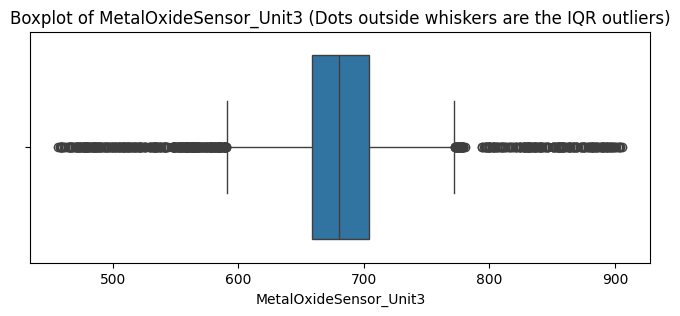

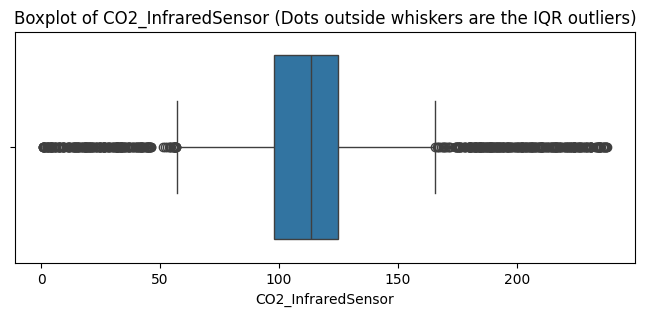

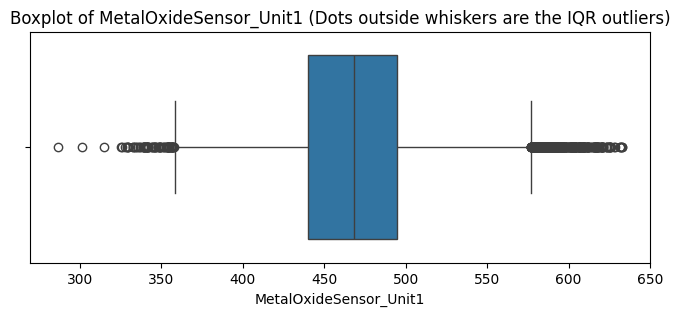

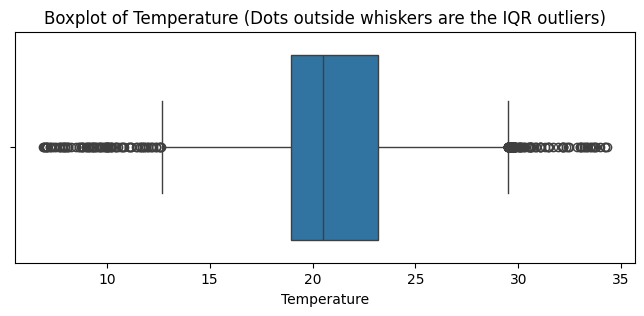

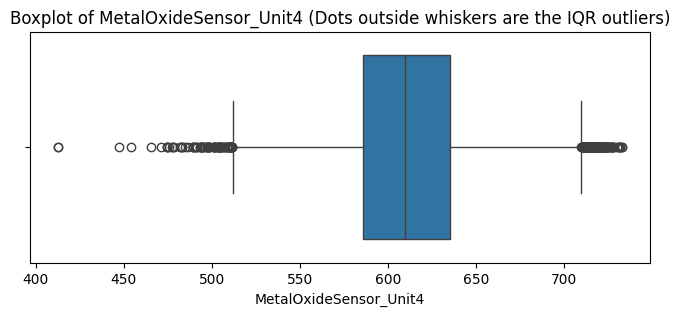

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

# Change column name to whatever showed the highest outlier count
top_outlier_col = iqr_summary.sort_values(by='Outlier Count', ascending=False).index[0]
for x in range(5):
    outlier_col = iqr_summary.sort_values(by='Outlier Count', ascending=False).index[x]
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_clean[outlier_col])
    plt.title(f"Boxplot of {outlier_col} (Dots outside whiskers are the IQR outliers)")
    plt.show()

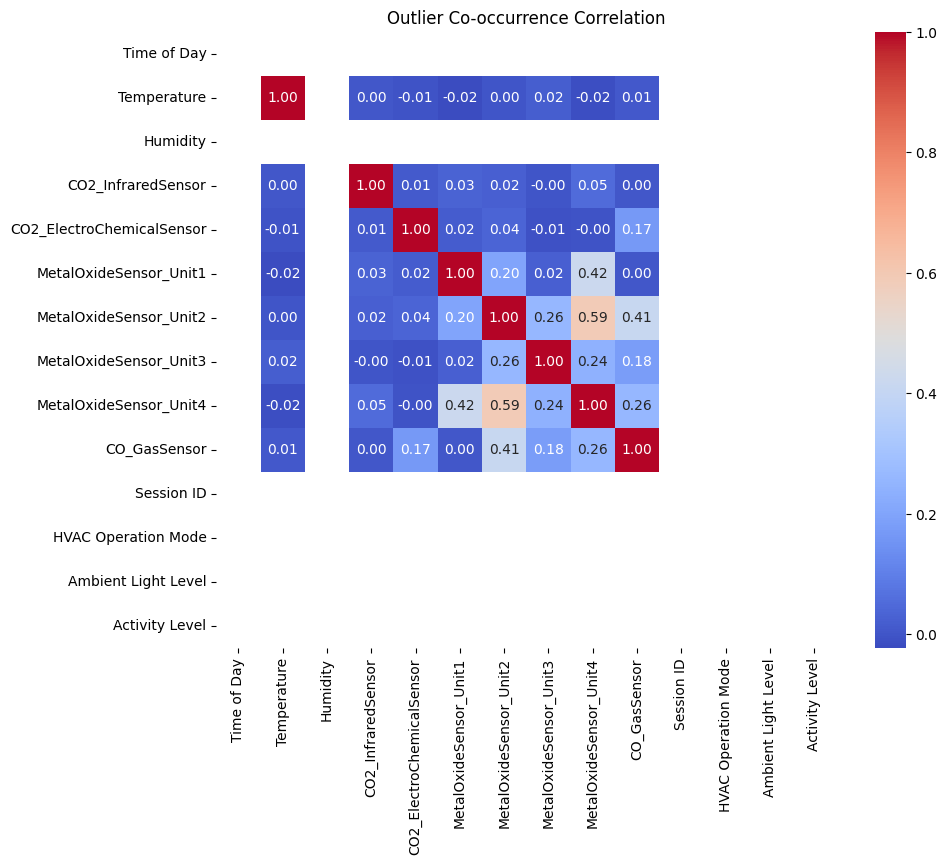

In [112]:


plt.figure(figsize=(10, 8))
sns.heatmap(outliers_mask.astype(int).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Outlier Co-occurrence Correlation')
plt.show()

True Outliers vs. Heavy Tails

the 'outliers' are natural and are intense spikes that happened naturally / caused by something

CHECKING CO2_GAS

In [113]:
for level, group in df_clean.groupby('CO_GasSensor'):
    print(f"\n--- CO_GasSensor Lffevel: {level} ---")
    print(group[['CO2_ElectroChemicalSensor', 'CO2_InfraredSensor']].describe())


--- CO_GasSensor Lffevel: 0.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                  954.00000          954.000000
mean                   603.75914           80.916384
std                     18.30932           32.859684
min                    553.78000            1.490000
25%                    591.19500           65.800000
50%                    607.20500           74.620000
75%                    617.94750           85.740000
max                    637.90000          237.770000

--- CO_GasSensor Lffevel: 1.0 ---
       CO2_ElectroChemicalSensor  CO2_InfraredSensor
count                3822.000000         3822.000000
mean                  579.788352          111.912268
std                    20.508342           28.700248
min                   535.030000            0.720000
25%                   560.302500          100.620000
50%                   583.180000          112.500000
75%                   595.242500          122.770000
max                   630.120

CHECKING HVAC correlation

In [114]:
df_clean["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
1    1272
4    1267
5    1246
3    1244
2    1215
6    1164
Name: count, dtype: int64

In [115]:
from scipy import stats

numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity', 'Activity Level'
]

print("=== Kruskal-Wallis Test: HVAC Operation Mode vs Numerical Features ===\n")

results = []
for col in numerical_cols:
    # Group each numerical column by HVAC mode
    groups = [group[col].dropna().values for _, group in df_clean.groupby('HVAC Operation Mode')]
    stat, p = stats.kruskal(*groups)
    results.append({'Feature': col, 'H-Statistic': round(stat, 4), 'p-value': round(p, 4)})

results_df = pd.DataFrame(results).sort_values('p-value')
print(results_df)

=== Kruskal-Wallis Test: HVAC Operation Mode vs Numerical Features ===

                     Feature  H-Statistic  p-value
9             Activity Level       7.2281   0.2042
4                Temperature       6.6132   0.2510
7  CO2_ElectroChemicalSensor       4.8136   0.4391
5     MetalOxideSensor_Unit2       4.0725   0.5390
6               CO_GasSensor       2.5852   0.7636
2     MetalOxideSensor_Unit1       1.7626   0.8809
3     MetalOxideSensor_Unit4       1.7627   0.8809
0     MetalOxideSensor_Unit3       1.7569   0.8817
1         CO2_InfraredSensor       1.2660   0.9384
8                   Humidity       0.7104   0.9824


Kruskal-Wallis Test: used to compare three or more independent groups to determine if there are statistically significant differences between them

"Do sensor readings differ significantly between HVAC modes?"

H-statistic is how much the distributions differ across groups. higher means how much change due to HVAC mode diff
p-value is the probability that the observed difference between groups happened by random chance. lower btr
    
    Temperature is most affected by HVAC and Activity Level, high p value indicates there still isnt much differences between modes even for those two

     p ≥ 0.05 → fail to reject the null (no evidence of difference)


Feature importance

In [116]:
from sklearn.feature_selection import mutual_info_classif

X = df_clean[numerical_cols]
y = df_clean['HVAC Operation Mode'].astype(int)
mi = mutual_info_classif(X, y, random_state=42)

pd.Series(mi, index=X.columns).sort_values(ascending=False)

CO2_ElectroChemicalSensor    0.059323
MetalOxideSensor_Unit3       0.055963
Humidity                     0.050479
MetalOxideSensor_Unit1       0.049060
CO2_InfraredSensor           0.047757
MetalOxideSensor_Unit4       0.043709
MetalOxideSensor_Unit2       0.041944
Temperature                  0.035293
CO_GasSensor                 0.001830
Activity Level               0.000000
dtype: float64

MI is:

Non-linear
Non-parametric
Does not indicate positive or negative correlation

Results show weak to no correlation in all fields

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import pandas as pd

X = df_clean[numerical_cols]
y = df_clean['HVAC Operation Mode'].astype(int)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Built-in feature importance
builtin_imp = pd.Series(rf.feature_importances_, index=X.columns).rename('Built-in Importance')

# Permutation importance
perm_result = permutation_importance(rf, X, y, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm_result.importances_mean, index=X.columns).rename('Permutation Importance')

# Combine
importance_df = pd.concat([builtin_imp, perm_imp], axis=1).sort_values('Built-in Importance', ascending=False)
print(importance_df)

                           Built-in Importance  Permutation Importance
MetalOxideSensor_Unit1                0.121800                0.046045
Humidity                              0.121571                0.036596
CO2_ElectroChemicalSensor             0.120704                0.092778
CO2_InfraredSensor                    0.119972                0.040605
MetalOxideSensor_Unit3                0.119050                0.038728
MetalOxideSensor_Unit4                0.118239                0.022125
Temperature                           0.117946                0.070437
MetalOxideSensor_Unit2                0.116015                0.027038
Activity Level                        0.024715                0.000486
CO_GasSensor                          0.019989                0.000000


forest has bias towards numbers/high unique values and 'repeat' columns like co2 and oxide sensor affects Importance.
Permutation reduces it. Temperature is most important, Co2 electro is 'better' than co2 infared. Metal Oxide 4, CO_Gas and Activity Level are Useless

CHECKING ACTIVITY LEVEL

In [118]:
df_clean.groupby("Activity Level")[numerical_cols].median()

,MetalOxideSensor_Unit3,CO2_InfraredSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit4,Temperature,MetalOxideSensor_Unit2,CO_GasSensor,CO2_ElectroChemicalSensor,Humidity,Activity Level
Activity Level,,,,,,,,,,
1,666.730,117.540,458.00,594.265,21.500,714.710,1.0,568.745,51.830,1.0
2,698.010,104.775,486.27,629.940,19.455,740.815,1.0,589.975,50.240,2.0
3,690.735,110.775,473.38,619.360,19.705,734.720,1.0,586.940,51.745,3.0


In [119]:

print("=== Kruskal-Wallis Test: Activity Level vs Numerical Features ===\n")
numerical_cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity'
]
results = []
for col in numerical_cols:

    groups = [group[col].dropna().values for _, group in df_clean.groupby('Activity Level')]
    stat, p = stats.kruskal(*groups)
    results.append({'Feature': col, 'H-Statistic': round(stat, 4), 'p-value': round(p, 4)})

results_df = pd.DataFrame(results).sort_values('p-value')
print(results_df)


=== Kruskal-Wallis Test: Activity Level vs Numerical Features ===

                     Feature  H-Statistic  p-value
0     MetalOxideSensor_Unit3    1201.1072      0.0
1         CO2_InfraredSensor     569.4873      0.0
2     MetalOxideSensor_Unit1     733.5672      0.0
3     MetalOxideSensor_Unit4    1469.8333      0.0
4                Temperature     497.0427      0.0
5     MetalOxideSensor_Unit2    1600.7430      0.0
6               CO_GasSensor     820.7087      0.0
7  CO2_ElectroChemicalSensor     946.1637      0.0
8                   Humidity     203.3389      0.0


Every numerical sensor feature differs significantly across Activity Level groups (all p-values ≈ 0). This means the distributions of these sensor readings change as room activity changes. 

    Shows statistically significant differences between Activity Levels

/tmp/ipykernel_33838/3789887015.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity Level', y=top_feature, data=df_clean, palette='Set2')


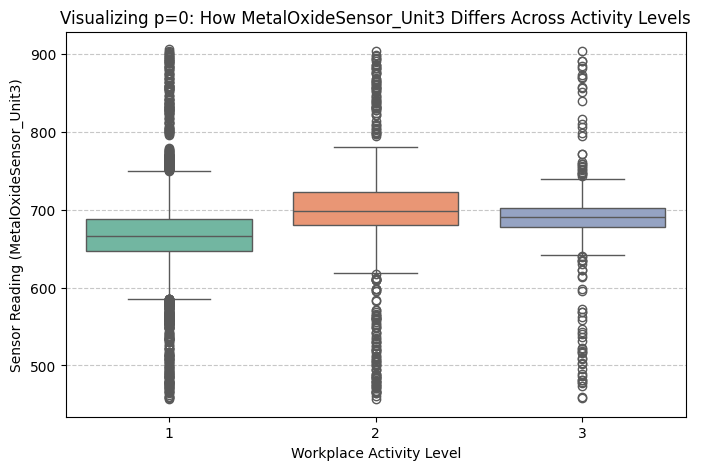

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick the feature that had the highest H-Statistic in your results_df
top_feature = results_df.iloc[0]['Feature']

plt.figure(figsize=(8, 5))
sns.boxplot(x='Activity Level', y=top_feature, data=df_clean, palette='Set2')
plt.title(f"Visualizing p=0: How {top_feature} Differs Across Activity Levels")
plt.ylabel(f"Sensor Reading ({top_feature})")
plt.xlabel("Workplace Activity Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

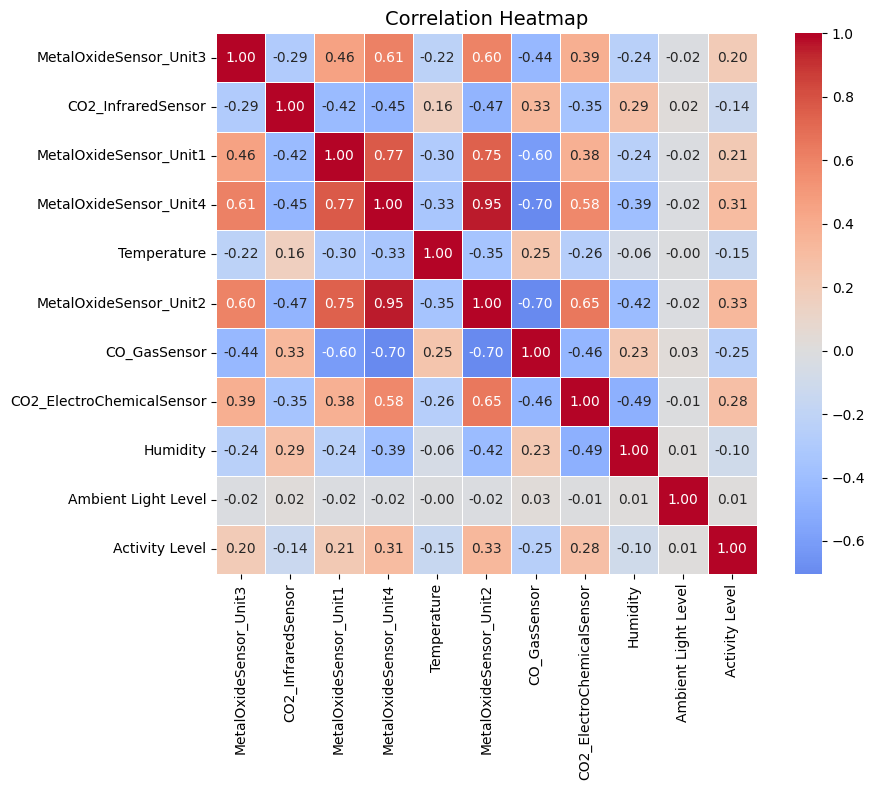

In [121]:
cols = [
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'Temperature', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity','Ambient Light Level', 'Activity Level'
]


# Compute correlation matrix
corr = df_clean[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,      # show correlation values inside cells
            cmap='coolwarm', # color scheme (red=negative, blue=positive)
            center=0,        # center colormap at zero
            square=True,     # square cells
            linewidths=0.5,  # grid lines
            fmt='.2f')       # format for annotations (2 decimals)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [128]:
cols = [
    'Temperature',
    'MetalOxideSensor_Unit3', 'CO2_InfraredSensor', 'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit4', 'MetalOxideSensor_Unit2',
    'CO_GasSensor', 'CO2_ElectroChemicalSensor', 'Humidity','Ambient Light Level', 'Activity Level'
]
df_clean.groupby("Time of Day")[cols].mean()

,Temperature,MetalOxideSensor_Unit3,CO2_InfraredSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit4,MetalOxideSensor_Unit2,CO_GasSensor,CO2_ElectroChemicalSensor,Humidity,Ambient Light Level,Activity Level
Time of Day,,,,,,,,,,,
1,19.501429,697.986120,104.861432,500.327075,635.545296,744.098643,1.042261,583.041202,51.881668,3.823271,1.663557
2,20.838963,693.298381,100.870927,488.006731,628.517548,739.530466,1.002603,584.020588,49.797356,3.857887,1.609578
3,23.644120,660.935814,119.710752,443.882742,587.283548,711.188854,1.643591,573.549600,48.826631,3.846944,1.369930
4,20.929772,669.912935,120.391823,450.447676,597.130798,718.484434,1.497797,573.928018,53.100143,3.925110,1.515419


Elderly tend to move around a little but less in the evening, this is reflected in co2 sensor as well

Light level appears to be consistently high while temperature is low

In [123]:

df_legend.to_csv('df_legend.csv', index=False)

df_clean.to_csv('df_clean.csv', index=False)